In [1]:
import pandas as pd
df = pd.read_csv("df_completo.csv")

In [2]:
df

,fecha,mayorista,minorista,pdf_file,dia_pdf,mes_pdf_txt,anio_pdf,mes_pdf,fecha_pdf,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_la_libertad(soles/kg),precio_lima(soles/kg)
0,2025-09-03,5.70,7.15,16_setiembre_2025.pdf,16.0,setiembre,2025.0,9.0,2025-09-16,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,4.9,5.50
1,2025-09-04,5.70,7.15,17_setiembre_2025.pdf,17.0,setiembre,2025.0,9.0,2025-09-17,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,4.8,5.50
2,2025-09-05,5.65,7.12,18_setiembre_2025.pdf,18.0,setiembre,2025.0,9.0,2025-09-18,103191.0,62557.0,0.0,9598.0,9944.0,185290.0,5.19,4.7,5.50
3,2025-09-06,5.65,7.12,19_setiembre_2025.pdf,19.0,setiembre,2025.0,9.0,2025-09-19,97955.0,72622.0,0.0,6363.0,4969.0,181909.0,5.22,4.6,5.40
4,2025-09-07,5.65,7.12,19_setiembre_2025.pdf,19.0,setiembre,2025.0,9.0,2025-09-19,24295.0,0.0,0.0,0.0,0.0,24295.0,4.90,NaN,5.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,2026-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.03,NaN,4.03
223,2026-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.86,NaN,4.32
224,2026-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.07,NaN,5.83
225,2026-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.95,NaN,5.83


In [85]:
# fecha mínima
min = df["fecha"].min()
print(min)
# fecha máxima
max = df["fecha"].max()
print(max)

2025-08-31
2026-04-22


# RELLENAMOS las fechas faltantes

In [5]:
# obtenemos la fecha del día de hoy
from datetime import datetime
hoy = datetime.now().date()
hoy # nota: esto debemos normalizarlo

datetime.date(2026, 4, 24)

In [ ]:
df["fecha"] = pd.to_datetime(df["fecha"])

# creamos CALENDARIO (freq = D)
calendario = pd.DataFrame({
    "fecha": pd.date_range(
        start="2025-08-31",
        end="2026-04-22",
        freq="D"
    )
})

# FECHA: lunes, martes, jueves, viernes, sábado, domingo 

#  Hacer merge para que aparezcan los días faltantes como NaN
df_full = calendario.merge(df, on="fecha", how="left")

In [87]:
df = df_full.copy()

In [88]:
# eliminar algunas columnas
df.drop(columns=['pdf_file','dia_pdf','mes_pdf_txt', 'anio_pdf', 'mes_pdf', 'fecha_pdf'], inplace=True)

In [89]:
df.isnull().sum()

fecha                             0
mayorista                        25
minorista                        45
oferta_lima(ton)                 25
oferta_sierra(ton)               25
oferta_costa_norte(ton)          25
oferta_selva(ton)                25
oferta_costa_sur(ton)            25
total(ton)                       25
precio_ica(soles/kg)             14
precio_la_libertad(soles/kg)    132
precio_lima(soles/kg)            13
dtype: int64

In [90]:
df

,fecha,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_la_libertad(soles/kg),precio_lima(soles/kg)
0,2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,NaN,5.90
1,2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.00,5.90
2,2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.00,5.90
3,2025-09-03,5.70,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,4.90,5.50
4,2025-09-04,5.70,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,4.80,5.50
...,...,...,...,...,...,...,...,...,...,...,...,...
230,2026-04-18,6.23,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,NaN,6.48
231,2026-04-19,6.23,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,NaN,6.48
232,2026-04-20,6.15,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,NaN,5.80
233,2026-04-21,6.15,7.44,136093.0,121187.0,6215.0,11891.0,0.0,275386.0,5.88,5.25,5.80


In [8]:
45/235

0.19148936170212766

In [9]:
132/235 # nos falta casi la mitad de datos para precio_la_libertad(soles/kg)    132

35/235 # nos falta el 10% de los datos para la mayoría de las variables

45/235 # casi 20% faltante en la variable nminorista

0.19148936170212766

nota

Ica: Es el líder indiscutible con un 40% a 42% de la participación nacional. Es el "núcleo" que regula la oferta real que llega a los mercados mayoristas.

Lima: Aporta cerca del 26% a 27%. Aunque ha perdido el liderazgo frente a Ica, sigue siendo crítica por su cercanía al mayor centro de consumo.

La Libertad: Contribuye con un 17% a 18%, consolidándose como el tercer eje productivo más importante del país.

In [92]:
# como precio_la_libertad(soles/kg) tiene 50% de nulos y la libertad aporta poco la eliminamos
df.drop(columns=["precio_la_libertad(soles/kg)"], inplace=True)

In [93]:
df

,fecha,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg)
0,2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90
1,2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90
2,2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90
3,2025-09-03,5.70,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50
4,2025-09-04,5.70,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50
...,...,...,...,...,...,...,...,...,...,...,...
230,2026-04-18,6.23,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48
231,2026-04-19,6.23,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48
232,2026-04-20,6.15,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80
233,2026-04-21,6.15,7.44,136093.0,121187.0,6215.0,11891.0,0.0,275386.0,5.88,5.80


# Analisis del patrón de datos faltantes

In [64]:
!pip install missingno


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


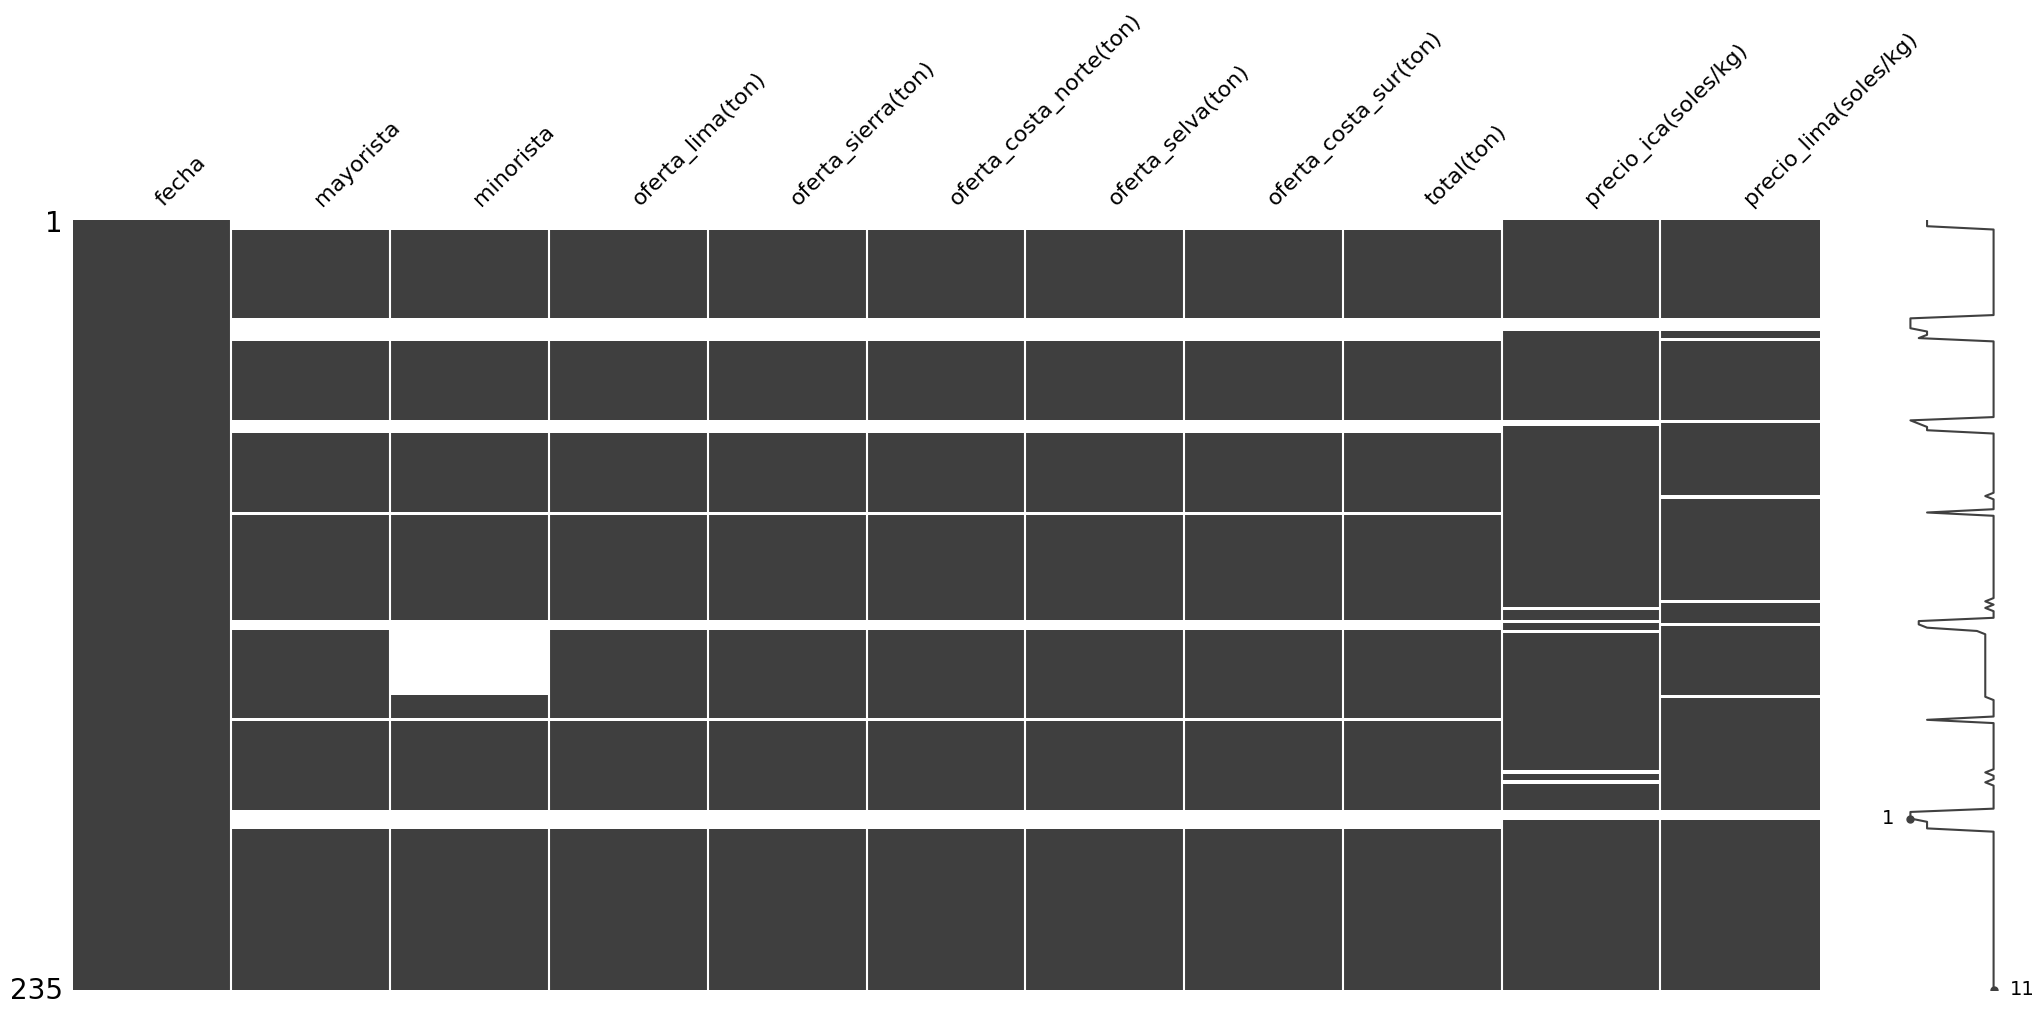

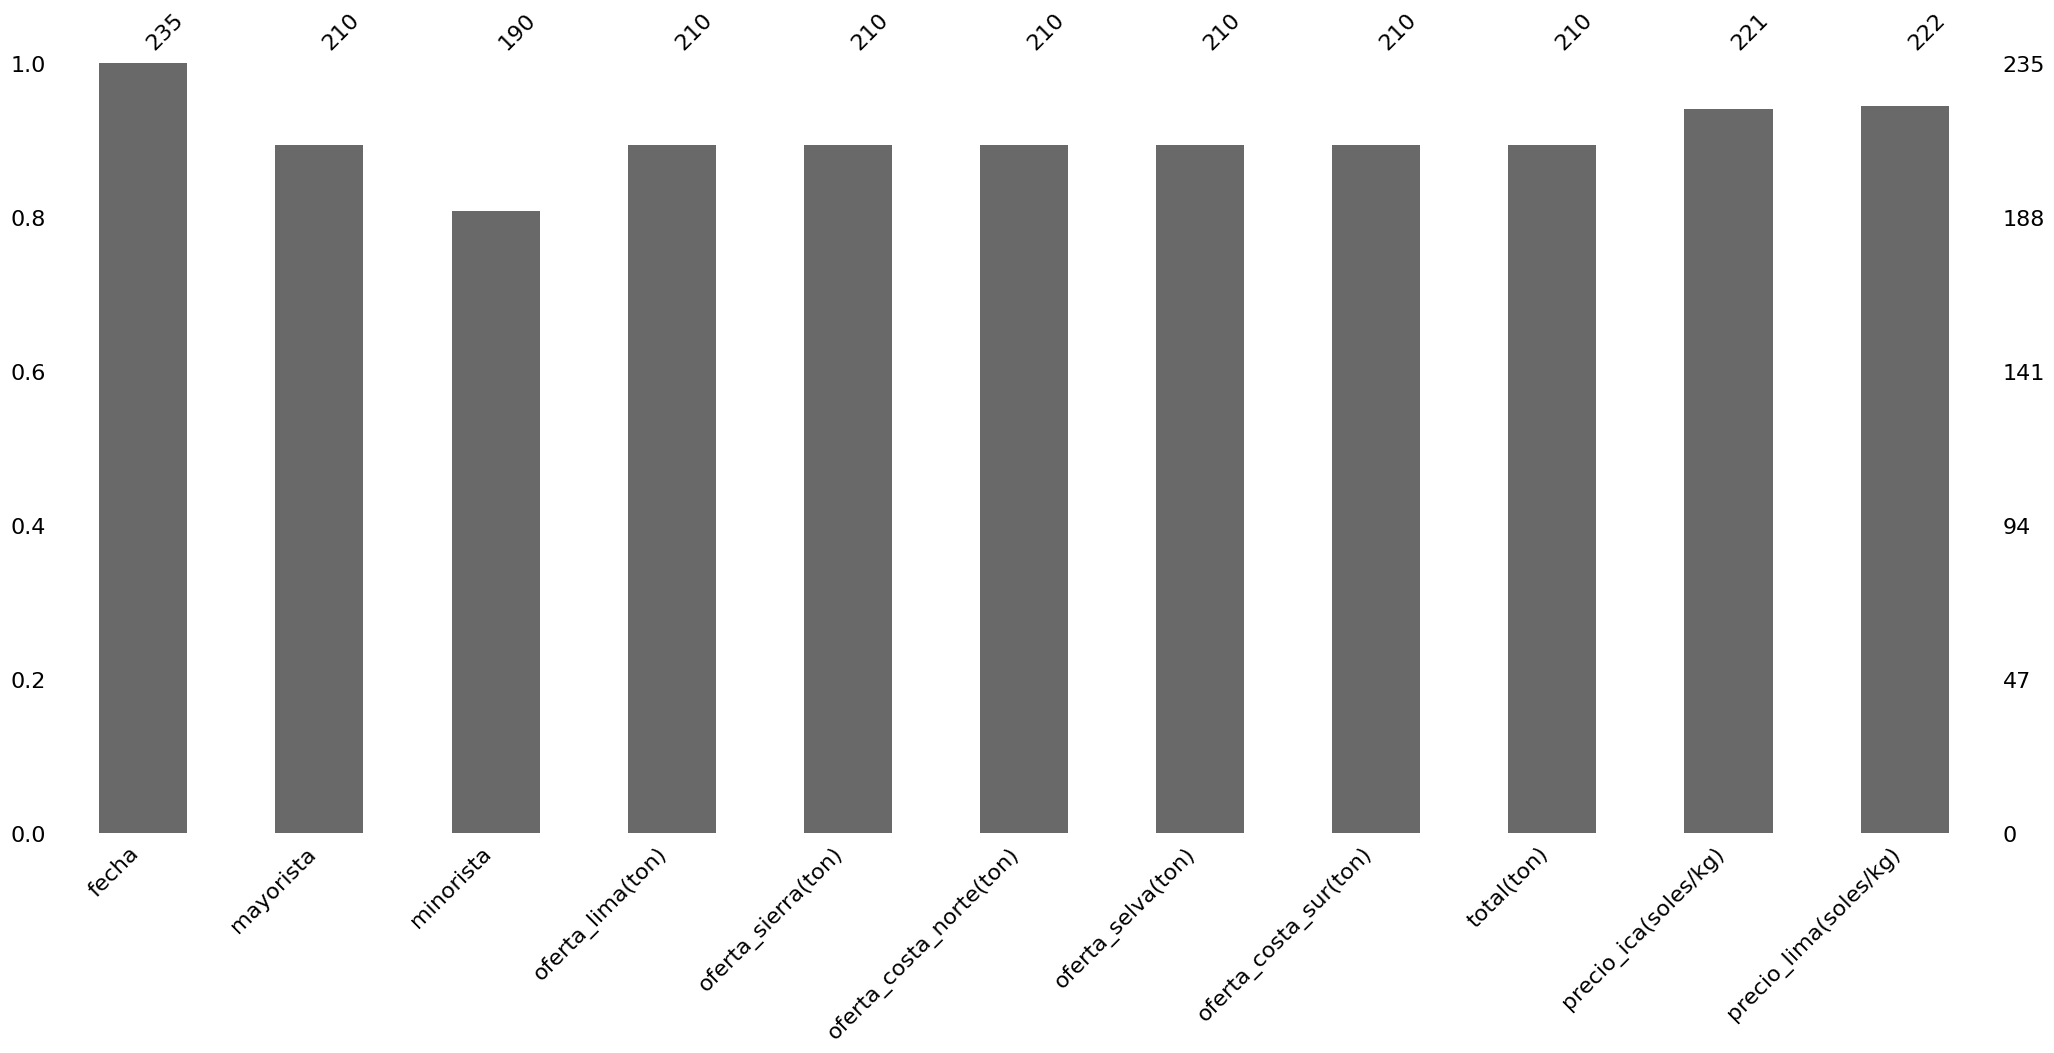

In [65]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# 1. Matriz de datos faltantes (los blancos son faltantes)
msno.matrix(df)
plt.show()

msno.bar(df)
plt.show()

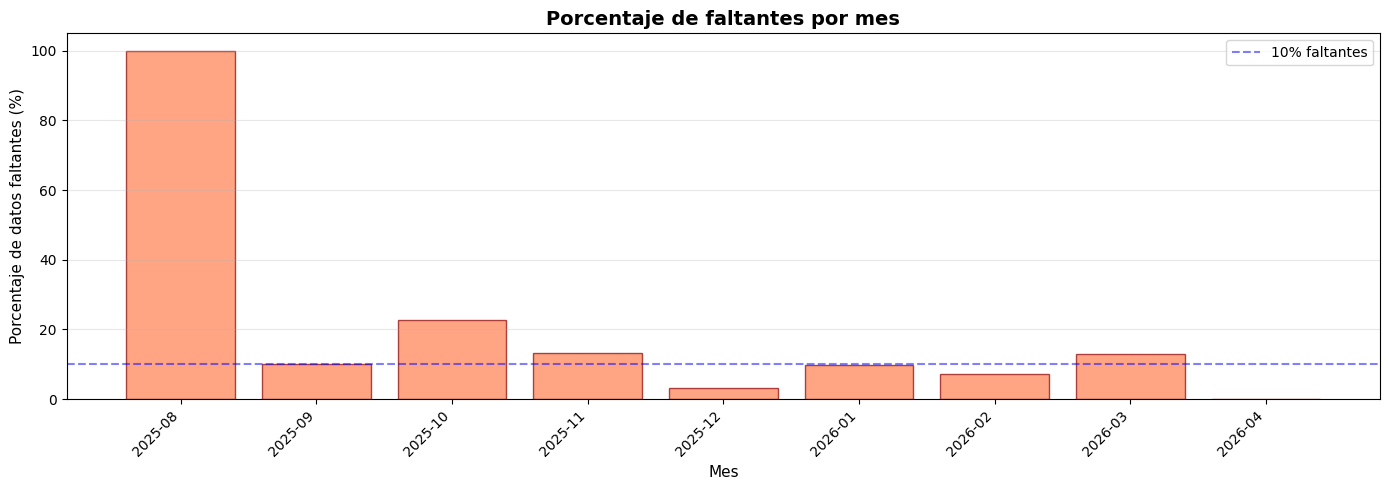

In [66]:
# Agrupar por mes y contar faltantes
df["año_mes"] = df["fecha"].dt.to_period("M")
faltantes_por_mes = df.groupby("año_mes")["mayorista"].apply(lambda x: x.isnull().sum())
dias_por_mes = df.groupby("año_mes")["mayorista"].count()
porcentaje_faltantes_mes = (faltantes_por_mes / (faltantes_por_mes + dias_por_mes)) * 100

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(porcentaje_faltantes_mes.index.astype(str), 
       porcentaje_faltantes_mes.values, 
       color='coral', edgecolor='darkred', alpha=0.7)

ax.set_xlabel("Mes", fontsize=11)
ax.set_ylabel("Porcentaje de datos faltantes (%)", fontsize=11)
ax.set_title("Porcentaje de faltantes por mes", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Línea de referencia (10%)
ax.axhline(y=10, color='blue', linestyle='--', alpha=0.5, label='10% faltantes')
ax.legend()

plt.tight_layout()
plt.show()

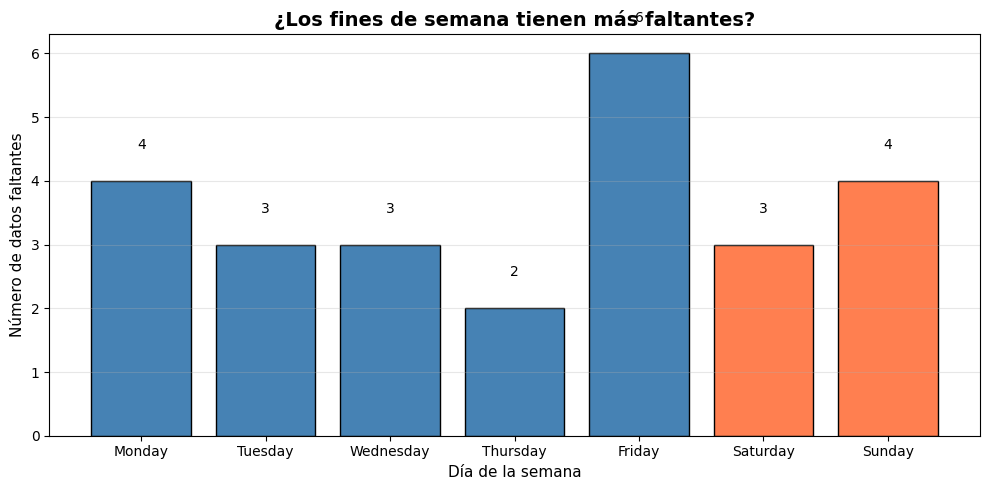

In [67]:
# no parece haber un patrón por mes, quizá por fin de semana o fin de mes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Asegurar que fecha sea datetime
df["fecha"] = pd.to_datetime(df["fecha"])

# Crear columna con nombre del día (para gráfico más claro)
df["nombre_dia"] = df["fecha"].dt.day_name()  # Monday, Tuesday, etc.

# Contar faltantes por día de la semana
faltantes_por_dia = df.groupby("nombre_dia")["mayorista"].apply(
    lambda x: x.isnull().sum()
)
# Ordenar de lunes a domingo
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
faltantes_por_dia = faltantes_por_dia.reindex(orden_dias)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['steelblue']*5 + ['coral', 'coral']  # Resaltar fines de semana
ax.bar(faltantes_por_dia.index, faltantes_por_dia.values, color=colores, edgecolor='black')

ax.set_xlabel("Día de la semana", fontsize=11)
ax.set_ylabel("Número de datos faltantes", fontsize=11)
ax.set_title("¿Los fines de semana tienen más faltantes?", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas con los valores
for i, v in enumerate(faltantes_por_dia.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

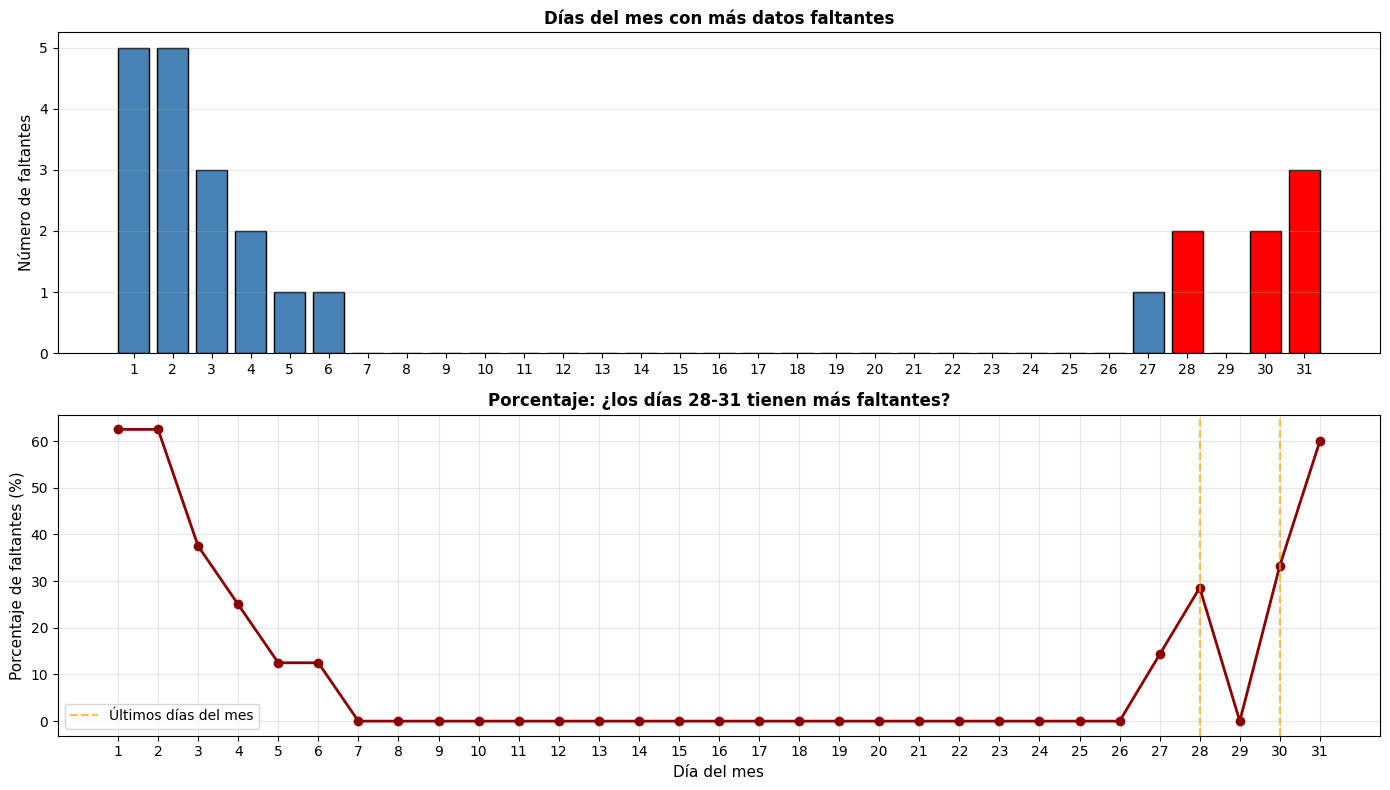

=== Días con mayor porcentaje de faltantes ===
Día 1: 62.5% faltantes
Día 2: 62.5% faltantes
Día 31: 60.0% faltantes
Día 3: 37.5% faltantes
Día 30: 33.3% faltantes
Día 28: 28.6% faltantes
Día 4: 25.0% faltantes
Día 27: 14.3% faltantes
Día 6: 12.5% faltantes
Día 5: 12.5% faltantes


In [94]:
# Extraer día del mes
df["dia_del_mes"] = df["fecha"].dt.day

# Contar faltantes por día del mes (1, 2, 3, ..., 31)
faltantes_por_dia_mes = df.groupby("dia_del_mes")["mayorista"].apply(
    lambda x: x.isnull().sum()
)
total_por_dia_mes = df.groupby("dia_del_mes")["mayorista"].count()
porcentaje_faltantes = (faltantes_por_dia_mes / (faltantes_por_dia_mes + total_por_dia_mes)) * 100

# Gráfico
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico de barras superiores (conteo absoluto)
colores_barra = ['red' if d >= 28 else 'steelblue' for d in range(1, 32)]
ax1.bar(range(1, 32), faltantes_por_dia_mes.values, color=colores_barra, edgecolor='black')
ax1.set_ylabel("Número de faltantes", fontsize=11)
ax1.set_title("Días del mes con más datos faltantes", fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 32))
ax1.grid(True, alpha=0.3, axis='y')

# Gráfico de líneas inferiores (porcentaje)
ax2.plot(range(1, 32), porcentaje_faltantes.values, 'o-', color='darkred', linewidth=2, markersize=6)
ax2.axvline(x=28, color='orange', linestyle='--', alpha=0.7, label='Últimos días del mes')
ax2.axvline(x=30, color='orange', linestyle='--', alpha=0.7)
ax2.set_xlabel("Día del mes", fontsize=11)
ax2.set_ylabel("Porcentaje de faltantes (%)", fontsize=11)
ax2.set_title("Porcentaje: ¿los días 28-31 tienen más faltantes?", fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 32))
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Imprimir resumen
print("=== Días con mayor porcentaje de faltantes ===")
top_dias = porcentaje_faltantes.sort_values(ascending=False).head(10)
for dia, pct in top_dias.items():
    print(f"Día {dia}: {pct:.1f}% faltantes")

Dado que hemos visto que los datos faltantes de df[MAYORISTA] usualmente están al inicio y al final del mes, conviene usar una Imputación por "mismo día de mercado" o "ventanas centradas en días similares"


# Imputación por Calendarización

En la literatura estadística, pertenece a la familia de métodos basados en estacionalidad (seasonality-based methods) y series temporales con efectos fijos (fixed effects time series).


Se identificó un patrón sistemático de datos faltantes concentrado principalmente en los primeros y últimos días del mes. Por ello, los faltantes no fueron tratados como completamente aleatorios. Se completó el calendario diario de observaciones y se aplicó imputación temporal, conservando una variable indicadora de imputación para controlar el efecto de estos registros en el análisis posterior.[]

In [95]:
df

,fecha,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes
0,2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31
1,2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1
2,2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2
3,2025-09-03,5.70,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3
4,2025-09-04,5.70,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4
...,...,...,...,...,...,...,...,...,...,...,...,...
230,2026-04-18,6.23,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18
231,2026-04-19,6.23,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19
232,2026-04-20,6.15,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20
233,2026-04-21,6.15,7.44,136093.0,121187.0,6215.0,11891.0,0.0,275386.0,5.88,5.80,21


In [96]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.set_index("fecha")

In [97]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes
fecha,,,,,,,,,,,
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1
2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2
2025-09-03,5.70,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3
2025-09-04,5.70,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.23,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18
2026-04-19,6.23,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19
2026-04-20,6.15,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20


In [98]:
df["mayorista_original"] = df["mayorista"]

In [99]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original
fecha,,,,,,,,,,,,
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN
2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN
2025-09-03,5.70,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70
2025-09-04,5.70,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.23,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23
2026-04-19,6.23,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23
2026-04-20,6.15,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15


In [100]:
# cramos la columan dia_mes
df["dia_mes"] = df.index.day

In [101]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.70,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.70,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.23,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.23,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.15,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


In [76]:
# Días con más faltantes (según tu análisis)
primeros_dias = [1, 2, 3, 4, 5, 6]
ultimos_dias = [25, 26, 27, 28, 29, 30, 31]


Funcion para buscar el mismo día en otro mes

In [77]:
def buscar_mismo_dia(df, fecha_actual, dias_a_mover=1, direccion="atras"):
    """
    Busca el mismo día del mes en una fecha anterior o posterior
    
    Parámetros:
    - df: DataFrame con índice datetime
    - fecha_actual: la fecha desde donde buscamos
    - dias_a_mover: cuántos meses mover (1, 2, 3...)
    - direccion: "atras" o "adelante"
    
    Retorna:
    - El valor si existe, None si no
    """
    if direccion == "atras":
        nueva_fecha = fecha_actual - pd.DateOffset(months=dias_a_mover)
    else:
        nueva_fecha = fecha_actual + pd.DateOffset(months=dias_a_mover)
    
    # Ajustar al mismo día del mes (ej: 31 de febrero → 28 de febrero)
    dia_objetivo = fecha_actual.day
    while nueva_fecha.day != dia_objetivo:
        if direccion == "atras":
            nueva_fecha = nueva_fecha - pd.DateOffset(days=1)
        else:
            nueva_fecha = nueva_fecha + pd.DateOffset(days=1)
        
        # Si nos salimos del rango, no hay valor
        if nueva_fecha < df.index.min() or nueva_fecha > df.index.max():
            return None
    
    # Buscar el valor en el DataFrame
    if nueva_fecha in df.index:
        valor = df.loc[nueva_fecha, "mayorista"]
        if pd.notna(valor):
            return valor
    
    return None

In [102]:
# Trabajar sobre una copia
df_imputado = df.copy()

# Contadores para saber cuánto imputamos con cada método
contadores = {
    "mes_anterior_1": 0,
    "mes_anterior_2": 0,
    "mes_anterior_3": 0,
    "mes_siguiente": 0
}

Imputar los primeros días

In [103]:

for dia in primeros_dias:
    # Filtrar filas donde falta el dato y es este día
    mask = (df_imputado["mayorista"].isna()) & (df_imputado["dia_mes"] == dia)
    indices_faltantes = df_imputado[mask].index
    
    for fecha in indices_faltantes:
        # Intentar con mes anterior
        valor = buscar_mismo_dia(df_imputado, fecha, dias_a_mover=1, direccion="atras")
        
        if valor is not None:
            df_imputado.loc[fecha, "mayorista"] = valor
            contadores["mes_anterior_1"] += 1

print(f"    Imputados con mes anterior: {contadores['mes_anterior_1']}")

    Imputados con mes anterior: 11


Imputar los últimos días

In [104]:

for dia in ultimos_dias:
    mask = (df_imputado["mayorista"].isna()) & (df_imputado["dia_mes"] == dia)
    indices_faltantes = df_imputado[mask].index
    
    for fecha in indices_faltantes:
        # PRIMERO: intentar con mes anterior
        valor = buscar_mismo_dia(df_imputado, fecha, dias_a_mover=1, direccion="atras")
        
        if valor is not None:
            df_imputado.loc[fecha, "mayorista"] = valor
            contadores["mes_anterior_1"] += 1
            continue
        
        # SEGUNDO: intentar con mes siguiente
        valor = buscar_mismo_dia(df_imputado, fecha, dias_a_mover=1, direccion="adelante")
        
        if valor is not None:
            df_imputado.loc[fecha, "mayorista"] = valor
            contadores["mes_siguiente"] += 1

print(f"    Imputados con mes anterior: {contadores['mes_anterior_1'] - 6}" if contadores['mes_anterior_1'] > 6 else "")
print(f"    Imputados con mes siguiente: {contadores['mes_siguiente']}")

    Imputados con mes anterior: 9
    Imputados con mes siguiente: 2


In [105]:
df_imputado.isnull().sum()

mayorista                   8
minorista                  45
oferta_lima(ton)           25
oferta_sierra(ton)         25
oferta_costa_norte(ton)    25
oferta_selva(ton)          25
oferta_costa_sur(ton)      25
total(ton)                 25
precio_ica(soles/kg)       14
precio_lima(soles/kg)      13
dia_del_mes                 0
mayorista_original         25
dia_mes                     0
dtype: int64

In [106]:
df_imputado[df_imputado["mayorista"].isna()]

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1
2025-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2
2025-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,31
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.55,1,NaN,1
2025-11-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.70,4.55,2,NaN,2


Día 31 de un mes → El mes anterior puede no tener día 31

Día 1 de un mes → A veces también falta el dato en el mes anterior

### para los 31s usaremos el diaanterior

In [108]:

def ultimo_dia_mes_anterior(df, fecha_actual):
    """Obtiene el último día del mes anterior"""
    primer_dia_mes_actual = fecha_actual.replace(day=1)
    ultimo_dia_mes_anterior = primer_dia_mes_actual - pd.DateOffset(days=1)
    
    if ultimo_dia_mes_anterior in df.index:
        valor = df.loc[ultimo_dia_mes_anterior, "mayorista"]
        if pd.notna(valor):
            return valor
    return None

# Contador para días 31
contador_31 = 0

for fecha in df_imputado[df_imputado["mayorista"].isna()].index:
    if fecha.day == 31:
        valor = ultimo_dia_mes_anterior(df_imputado, fecha)
        if valor is not None:
            df_imputado.loc[fecha, "mayorista"] = valor
            contador_31 += 1

print(f"    Días 31 imputados: {contador_31}")

    Días 31 imputados: 1


### para los 1s usaremos el 1 del mes anteiror

In [ ]:

# Para días 1 que aún faltan
contador_1 = 0

for fecha in df_imputado[df_imputado["mayorista"].isna()].index:
    if fecha.day == 1:
        # Probar con 2, 3, 4 meses atrás
        for meses in [2, 3, 4]:
            valor = buscar_mismo_dia(df_imputado, fecha, dias_a_mover=meses, direccion="atras")
            if valor is not None:
                df_imputado.loc[fecha, "mayorista"] = valor
                contador_1 += 1
                print(f"        Día 1 de {fecha.strftime('%Y-%m')} → {meses} meses atrás")
                break

print(f"    Días 1 imputados: {contador_1}")

🔧 Imputando días 1 (buscando en meses más atrás)...
    Días 1 imputados: 0


In [110]:
df_imputado.isnull().sum()

mayorista                   7
minorista                  45
oferta_lima(ton)           25
oferta_sierra(ton)         25
oferta_costa_norte(ton)    25
oferta_selva(ton)          25
oferta_costa_sur(ton)      25
total(ton)                 25
precio_ica(soles/kg)       14
precio_lima(soles/kg)      13
dia_del_mes                 0
mayorista_original         25
dia_mes                     0
dtype: int64

In [111]:
df_imputado[df_imputado["mayorista"].isna()]

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1
2025-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.55,1,NaN,1
2025-11-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.70,4.55,2,NaN,2


imputamos con media móvil con ventana dinámica

In [112]:
# Para los días 31, 1 y 2 que quedan: usar el promedio de los 3 días anteriores y 3 posteriores
df_imputado["mayorista"] = df_imputado["mayorista"].fillna(
    df_imputado["mayorista"].rolling(window=7, center=True, min_periods=2).mean()
)

In [113]:
df_imputado.isnull().sum()

mayorista                   1
minorista                  45
oferta_lima(ton)           25
oferta_sierra(ton)         25
oferta_costa_norte(ton)    25
oferta_selva(ton)          25
oferta_costa_sur(ton)      25
total(ton)                 25
precio_ica(soles/kg)       14
precio_lima(soles/kg)      13
dia_del_mes                 0
mayorista_original         25
dia_mes                     0
dtype: int64

In [114]:
df_imputado[df_imputado["mayorista"].isna()]

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.9,31,NaN,31


Ese día comienza nuesta serie po lo que no hay datos detrás

In [115]:
# Si es el primer día, usa el siguiente
df_imputado["mayorista"] = df_imputado["mayorista"].fillna(method="bfill")

# bfill Toma el próximo valor disponible (hacia adelante en el tiempo) y lo usa para llenar los NA anteriores.

C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_8868\1795307775.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_imputado["mayorista"] = df_imputado["mayorista"].fillna(method="bfill")


In [116]:
df_imputado.isnull().sum()

mayorista                   0
minorista                  45
oferta_lima(ton)           25
oferta_sierra(ton)         25
oferta_costa_norte(ton)    25
oferta_selva(ton)          25
oferta_costa_sur(ton)      25
total(ton)                 25
precio_ica(soles/kg)       14
precio_lima(soles/kg)      13
dia_del_mes                 0
mayorista_original         25
dia_mes                     0
dtype: int64

# descargamos

In [117]:
df_imputado.to_csv("df_completo_e_imputado.csv", index=True)